In [ ]:
import numpy as np
import pandas as pd
from vibes.absorbance_estimators.vibes import VibeSpec
from vibes.interference_models.pca import pca, loo_pca
import matplotlib.pyplot as plt
from vibes.utils.help_functions import vibes_help_fun
import multiprocessing as mp

In [3]:
Y = pd.read_parquet("../data/airmon/NO3/spectra.parquet")
Z = np.array(pd.read_parquet("../data/airmon/NO3/blanks.parquet"))

In [4]:
chat = loo_pca(Z)[1]

In [5]:
mu, _, _, W = pca(Z)
W = W[:,:chat]

In [6]:
mod = VibeSpec(c = chat)

In [7]:
mod.fit(Y.iloc[0].values, mu, W)

In [8]:
z,_ = mod.map_solver.solve(Y.iloc[0].values, mu, W)

In [9]:
Y.shape

(18, 2799)

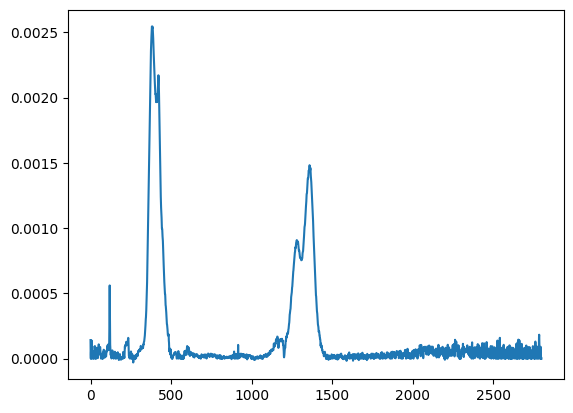

In [12]:
plt.plot(Y.iloc[0].values-z)

In [14]:
args = [(Y.iloc[i,:].values, mu, W, None, chat, "PB", 10000, Y.index[i]) for i in range(Y.shape[0])]

In [22]:
from tqdm import tqdm

In [23]:
res = []
for i in tqdm(range(Y.shape[0])):
    args = (Y.iloc[i,:].values, mu, W, None, chat, "PB", 10000, Y.index[i])
    res.append(vibes_help_fun(args))

100%|██████████| 18/18 [15:07<00:00, 50.40s/it]


{'sample_id': 'ammonium_nitrate_calibration_10_B',
 'absorbance': array([1.42064105e-04, 3.13215231e-05, 7.95585819e-13, ...,
        1.14729865e-05, 8.17850839e-06, 3.97881728e-12], shape=(2799,)),
 'time': 44.089062213897705,
 'sigma': np.float64(6.309304301752571e-06),
 'tau': np.float64(0.036227414048862275),
 'c': np.int64(220),
 'x': array([-2.05692754,  0.27821518, -1.07727369, -2.02390114, -0.81735517,
        -1.84267114, -2.26822831,  0.08206347,  1.15736513, -1.43590623,
         2.86306913,  0.10228963,  2.2499626 , -2.93885649,  1.4698226 ,
        -1.74814218, -3.049952  , -1.7748732 , -3.09477962, -1.79612038,
        -1.60684927,  0.8737    , -0.60391585,  1.02985795, -0.00355884,
        -0.04068293,  0.52232172,  1.3124981 ,  0.44932088,  0.65025849,
        -1.48539664, -0.85740271, -0.40423689, -0.52392083,  0.1792924 ,
         1.03597219, -0.85858079, -0.56753367, -1.3390325 ,  0.12536356,
         0.39025753, -0.14275177, -0.47023601,  0.64118274, -1.26219297,
  

In [17]:
#mp.cpu_count()
with mp.Pool(processes=1) as pool:
    res = list(pool.imap(vibes_help_fun, args))

KeyboardInterrupt: 

In [ ]:
with mp.Pool(processes=mp.cpu_count()) as pool:
        res = list(tqdm(pool.imap(vibes_help_fun, args),total=len(args),desc=f"Removing interference with: {pargs.loss} loss; c={pargs.c}; tau={pargs.tau}; mit={pargs.mit}",leave=False,))

In [22]:
res